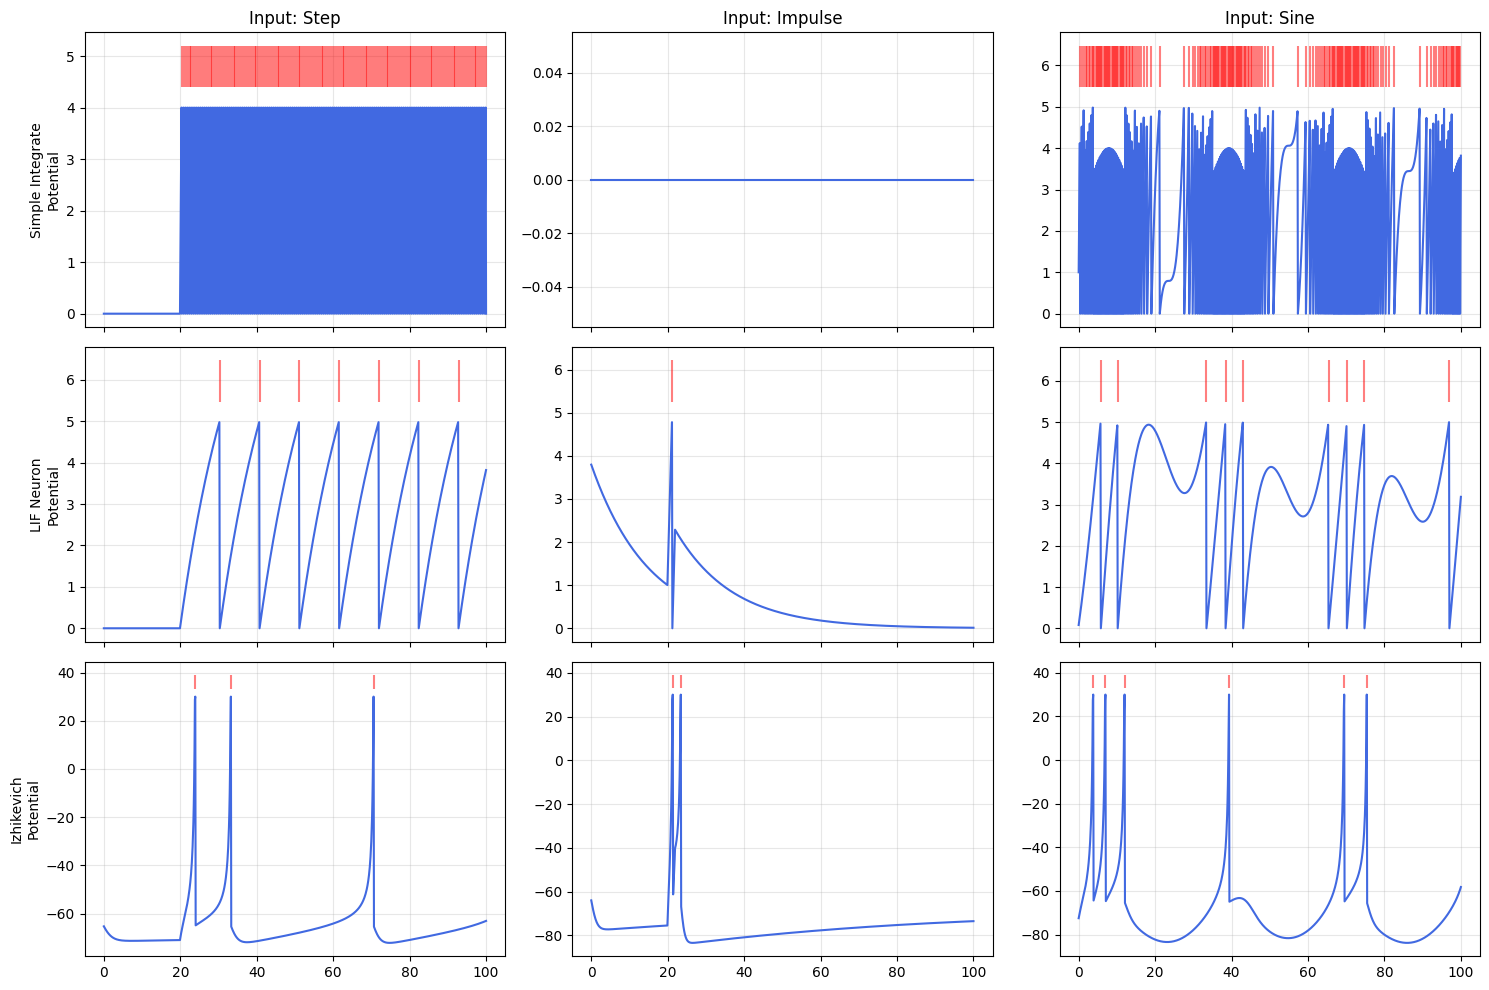

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleIntegrateFire:
    def __init__(self, threshold=1.0, reset=0.0):
        self.v = 0.0
        self.threshold = threshold
        self.reset = reset

    def step(self, I, dt=0.1):
        self.v += I * dt
        spike = 0
        if self.v >= self.threshold:
            spike = 1
            self.v = self.reset
        return self.v, spike

class LIFNeuron:
    def __init__(self, tau=10.0, v_rest=0.0, threshold=1.0, reset=0.0):
        self.v = v_rest
        self.tau = tau
        self.v_rest = v_rest
        self.threshold = threshold
        self.reset = reset

    def step(self, I, dt=0.1):
        dv = (-(self.v - self.v_rest) + I) / self.tau * dt
        self.v += dv
        spike = 0
        if self.v >= self.threshold:
            spike = 1
            self.v = self.reset
        return self.v, spike

class IzhikevichNeuron:
    def __init__(self, a=0.02, b=0.2, c=-65.0, d=8.0):
        self.v = -65.0
        self.u = b * self.v
        self.a, self.b, self.c, self.d = a, b, c, d

    def step(self, I, dt=0.1):
        dv = (0.04 * self.v**2 + 5 * self.v + 140 - self.u + I) * dt
        du = (self.a * (self.b * self.v - self.u)) * dt
        self.v += dv
        self.u += du
        
        spike = 0
        if self.v >= 30:
            spike = 1
            v_display = 30
            self.v = self.c
            self.u += self.d
            return v_display, spike
        return self.v, spike

T = 100
dt = 0.1
steps = int(T / dt)
time = np.linspace(0, T, steps)

inputs = {
    "Step": np.where(time > 20, 10, 0),
    "Impulse": np.where((time > 20) & (time < 22), 50, 0),
    "Sine": 10 * (np.sin(time / 5) + 1)
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
plt.subplots_adjust(hspace=0.3)

models_info = [
    ("Simple Integrate", SimpleIntegrateFire(threshold=5)),
    ("LIF Neuron", LIFNeuron(tau=15, threshold=5)),
    ("Izhikevich", IzhikevichNeuron(a=0.02, b=0.2, c=-65, d=6))
]

for col, (input_name, I_arr) in enumerate(inputs.items()):
    for row, (model_name, model) in enumerate(models_info):
        v_history = []
        spikes = []
        
        for I in I_arr:
            v, s = model.step(I, dt)
            v_history.append(v)
            spikes.append(s)
            
        ax = axes[row, col]
        ax.plot(time, v_history, color='royalblue', label='V')
        spike_times = time[np.array(spikes) > 0]
        ax.vlines(spike_times, ymin=max(v_history)*1.1, ymax=max(v_history)*1.3, color='red', alpha=0.5)
        
        if row == 0: ax.set_title(f"Input: {input_name}")
        if col == 0: ax.set_ylabel(f"{model_name}\nPotential")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()